In [9]:

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"  
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["ABSL_LOGGING_MIN_LEVEL"] = "3" 
os.environ["TF_DISABLE_PLUGIN_LOADING"] = "1"
os.environ["TF_DETERMINISTIC_OPS"] = "1"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
import warnings
warnings.filterwarnings('ignore')

In [10]:
titanic = sns.load_dataset('titanic')

In [11]:
X = titanic.loc[:, ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class']]
y = titanic['survived']

In [12]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   pclass    891 non-null    int64   
 1   sex       891 non-null    str     
 2   age       714 non-null    float64 
 3   sibsp     891 non-null    int64   
 4   parch     891 non-null    int64   
 5   fare      891 non-null    float64 
 6   embarked  889 non-null    str     
 7   class     891 non-null    category
dtypes: category(1), float64(2), int64(3), str(2)
memory usage: 49.9 KB


In [13]:
y.head()

0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

### Preparing the features

Use `OneHotEncoder` with `drop = 'if_binary'` on all categorical features. Use the `StandardScaler` on the remaining features. 

In [14]:
X['age'] = X['age'].fillna(X['age'].mean())


t = make_column_transformer((OneHotEncoder(drop='if_binary'),['sex', 'embarked', 'class']),
                           remainder=StandardScaler())
X_t = t.fit_transform(X)

X_t.shape

(891, 13)

### The Network Architecture

A sequantial network named `model` with one hidden layer with 100 dense units and a `relu` activation function.  The output layer of this model have one node and uses the `sigmoid` activation function.  

In [15]:
tf.random.set_seed(42)
model = Sequential([
    Dense(100, activation = 'relu'),
    Dense(1, activation = 'sigmoid')
])

model

<Sequential name=sequential_1, built=False>

### Train and Evaluate the Network

Finally, train and evaluate the network using the following compilation settings.  

- `optimizer = 'rmsprop'`
- `loss = 'bce'`
- `metrics = ['accuracy']`
- `epochs = 20`
- `batch_size = 10`
- `verbose = 0`

Also, be sure to leave the `tf.random.set_seed(42)` for proper grading.

In [23]:
model.compile(loss = 'bce', optimizer = 'rmsprop',
                     metrics = ['accuracy'])
np.random.seed(42)
history = model.fit(X_t, y, epochs = 20, batch_size = 10,
                           verbose = 0)

history.history['accuracy'][-1]

0.8585858345031738

### Another example

In [25]:

from sklearn.datasets import make_blobs

X, y = make_blobs([50, 50, 50, 50], centers = [[0, 5], [5, 0], [5, 5], [0, 0]],
                 random_state=42)

y[(y == 0) | (y == 1)] = 1
y[(y == 2) | (y == 3)] = 0

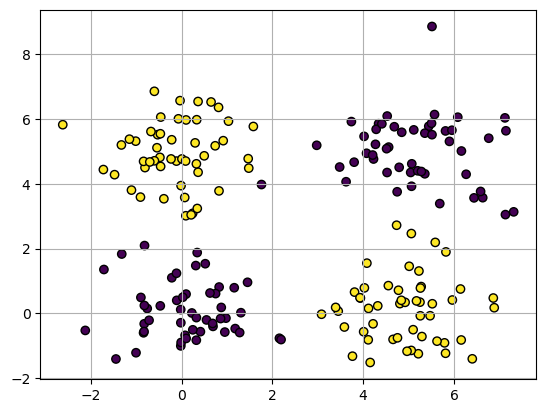

In [26]:
plt.scatter(X[:, 0], X[:, 1], c = y, edgecolor = 'black')
plt.grid();

In [27]:
model = Sequential([Dense(100, activation = 'relu'), 
                   Dense(1, activation = 'sigmoid')])
model.compile(loss = 'bce', metrics = ['acc'])
history = model.fit(X, y, epochs = 100, verbose = 0, validation_split = 0.2)


print(history.history['acc'][-1])

0.981249988079071


dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])


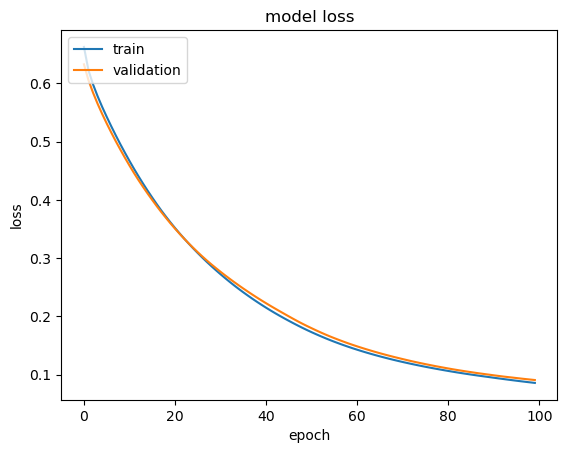

In [28]:
# create a visualization for the loss function

print(history.history.keys())
# "Loss"
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

#### How many epochs are necessary

epochs = 20(point of diminishing returns)